# 패키지 및 데이터

In [15]:
# =========================================================
# 기본 라이브러리
# =========================================================
from hossam import *

import numpy as np
import seaborn as sb
from matplotlib import pyplot as plt
from pandas import DataFrame, concat


# =========================================================
# scikit-learn: 전처리 / 파이프라인 / 데이터 분할
# =========================================================
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    learning_curve,
)


# =========================================================
# scikit-learn: 모델
# =========================================================
from sklearn.linear_model import LogisticRegression


# =========================================================
# scikit-learn: 성능 평가 지표
# =========================================================
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    log_loss
    
)


### 데이터

In [1]:
origin = load_data("pima_indians_diabetes_preprocessed")
origin.head()
origin.info()

캐글에서 제공하는 pima_indians_diabetes의 전처리 완료 버전(결측치 정제+로그변환) (출처: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    float64
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    float64
 8   Outcome                   768 non-null    int64  
dtypes: float64(7), int64(2)
memory usage: 54.1 KB


### 훈련, 검증 데이터 분리

In [6]:
df = origin.copy()

# 중요!!! 종속변수를 정수형으로 변환해야 한다.
df['Outcome'] = df['Outcome'].astype('int')
yname = "Outcome"
X = df.drop(columns=[yname])
y = df[yname]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state=52)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((614, 8), (154, 8), (614,), (154,))

### 로지스틱 모형 적합

In [ ]:
%%time

pipe = Pipeline([
    ("VIF_Selector", VIFSelector()),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=52))
])

param_grid = {
     "model__penalty": ["l2"],
    "model__solver": ["lbfgs"],
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__max_iter": [100, 300, 500],
    "model__class_weight": [None, "balanced"],
}

gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=1
)

gs.fit(X_train, y_train)

estimator = gs.best_estimator_
estimator


CPU times: total: 1.33 s
Wall time: 1.34 s
CPU times: total: 1.33 s
Wall time: 1.34 s


Pipeline(steps=[('VIF_Selector', VIFSelector()), ('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(C=1, class_weight='balanced',
                                    random_state=52))])

# 성능평가
 - 성능평가 함수


### 함수 정의

In [16]:
def hs_cls_bin_scores(estimator, X_test, y_test):
    # ===============================
    # 예측값 / 확률
    # ===============================
    y_pred_proba = estimator.predict_proba(X_test)[:, 1]
    y_pred = estimator.predict(X_test)

    # ===============================
    # McFadden pseudo R²
    # ===============================
    log_loss_test = -log_loss(y_test, y_pred_proba, normalize=False)

    y_null = np.ones_like(y_test) * (y_test.mean())
    log_loss_null = -log_loss(y_test, y_null, normalize=False)

    pseudo_r2 = 1 - (log_loss_test / log_loss_null)

    # ===============================
    # 혼동행렬
    # ===============================
    cm = confusion_matrix(y_test, y_pred)
    ((TN,FP), (FN, TP)) = cm

    # ===============================
    # 모델 클래스명
    # ===============================
    if hasattr(estimator, "named_steps"):
        class_name = estimator.named_steps["model"].__class__.__name__
    else:
        class_name = estimator.__class__.__name__

    # ===============================
    # AUC
    # ===============================
    auc_score = roc_auc_score(y_test, y_pred_proba)

    # ===============================
    # 성능 지표 DataFrame
    # ===============================
    score_df = DataFrame(
        {
            "의사결정계수(R2)": [pseudo_r2],
            "정확도(Accuracy)": [accuracy_score(y_test, y_pred)],
            "정밀도(Precision)": [precision_score(y_test, y_pred)],
            "재현율(Recall, TPR)": [recall_score(y_test, y_pred)],
            "위양성률(Fallout, FPR)": [FP / (TN + FP)],
            "특이성(TNR)": [TN / (TN + FP)],
            "F1 Score": [f1_score(y_test, y_pred)],
            "AUC": [auc_score],
        },
        index=[class_name],
    )

    # ===============================
    # ROC Curve
    # ===============================
    roc_fpr, roc_tpr, thresholds = roc_curve(y_test, y_pred_proba)

    my_dpi = 100
    width_px, height_px = 1000, 900
    rows, cols = 1, 1

    figsize = (width_px / my_dpi, height_px / my_dpi)
    fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

    sb.lineplot(x=roc_fpr, y=roc_tpr, ax=ax, label="ROC Curve")
    sb.lineplot(
        x=[0, 1],
        y=[0, 1],
        color="red",
        linestyle="--",
        alpha=0.5,
        ax=ax,
        label="Random",
    )

    ax.fill_between(roc_fpr, roc_tpr, alpha=0.1)

    ax.grid(True, alpha=0.3)
    ax.set_title(f"AUC = {auc_score:.4f}", fontsize=10, pad=4)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()

    plt.tight_layout()
    plt.show()
    plt.close()

    return score_df


### 함수 확인

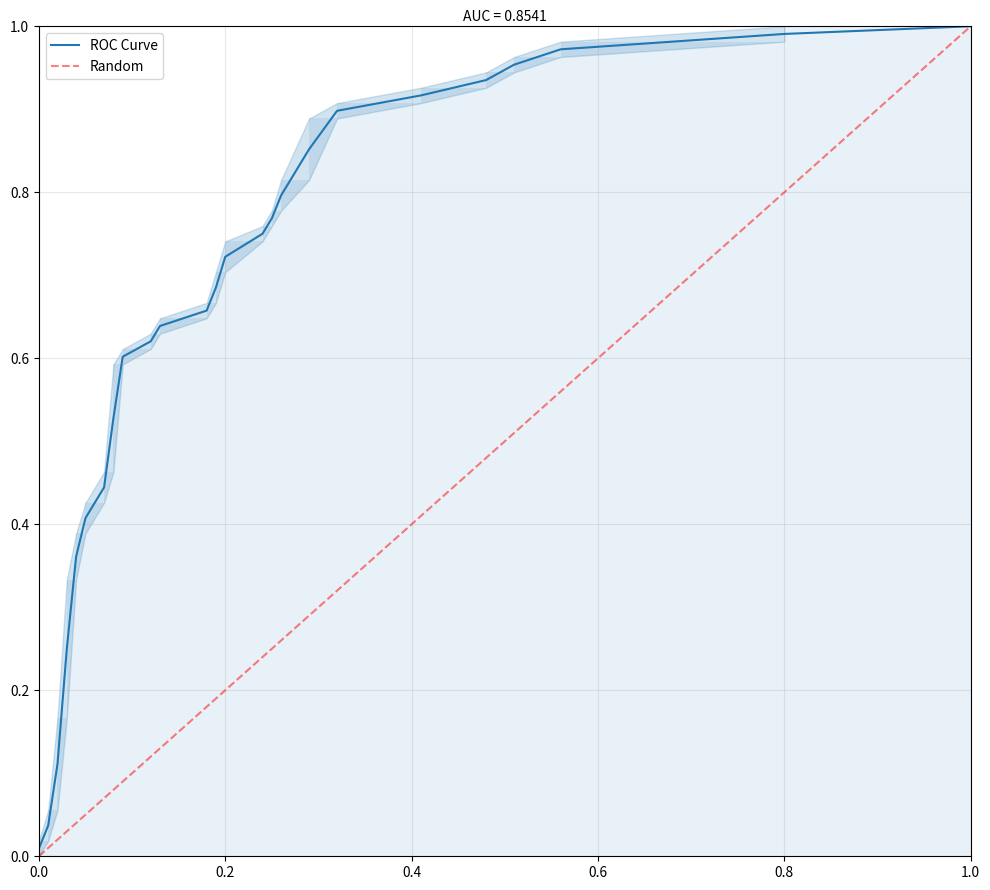

,의사결정계수(R2),정확도(Accuracy),정밀도(Precision),"재현율(Recall, TPR)","위양성률(Fallout, FPR)",특이성(TNR),F1 Score,AUC
LogisticRegression,0.226,0.766,0.629,0.815,0.260,0.740,0.710,0.854


In [17]:
hs_cls_bin_scores(estimator, X_test, y_test)

# 과적합 판정

### 함수 개선

In [18]:
def hs_learning_cv(
    estimator,
    X,
    y,
    scoring=None,          # None → 문제 유형에 따라 자동 설정
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
):
    # ==================================================
    # [NEW] 문제 유형 자동 판별
    # ==================================================
    is_classification = (
        hasattr(estimator, "_estimator_type")
        and estimator._estimator_type == "classifier"
    )

    # ==================================================
    # [NEW] scoring 자동 설정
    # ==================================================
    if scoring is None:
        scoring = (
            "roc_auc"
            if is_classification
            else "neg_root_mean_squared_error"
        )

    # ==================================================
    # learning curve 계산 (기존 동일)
    # ==================================================
    train_sizes, train_scores, cv_scores = learning_curve(  # type: ignore
        estimator=estimator,
        X=X,
        y=y,
        train_sizes=train_sizes,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        shuffle=False,
        random_state=52,
    )

    # ==================================================
    # 모델 클래스명 추출 (Pipeline 대응)
    # ==================================================
    if hasattr(estimator, "named_steps"):
        class_name = estimator.named_steps["model"].__class__.__name__
    else:
        class_name = estimator.__class__.__name__

    # ==================================================
    # 회귀 문제 처리
    # ==================================================
    if not is_classification:
        # neg RMSE → RMSE
        train_rmse = -train_scores
        cv_rmse = -cv_scores

        # 평균 / 표준편차
        train_mean = train_rmse.mean(axis=1)
        cv_mean = cv_rmse.mean(axis=1)
        cv_std = cv_rmse.std(axis=1)

        final_train = train_mean[-1]
        final_cv = cv_mean[-1]
        final_std = cv_std[-1]

        gap_ratio = final_train / final_cv
        var_ratio = final_std / final_cv

        # ------------------------------
        # 기준값 계산
        # ------------------------------
        y_mean = y.mean()
        rmse_naive = np.sqrt(np.mean((y - y_mean) ** 2))

        std_y = y.std()
        min_r2 = 0.10
        rmse_r2 = np.sqrt((1 - min_r2) * np.var(y))

        some_threshold = min(rmse_naive, std_y, rmse_r2)

        # ------------------------------
        # 판정 로직
        # ------------------------------
        train_slope = train_mean[-1] - train_mean[-2]
        cv_slope = cv_mean[-1] - cv_mean[-2]

        if gap_ratio > 0.95 and final_cv > some_threshold:
            status = "⚠️ 과소적합"
        elif gap_ratio < 0.8 and train_slope > 0 and cv_slope < 0:
            status = "⚠️ 데이터 추가 시 일반화 기대"
        elif gap_ratio <= 0.8:
            status = "⚠️ 과대적합"
        elif gap_ratio <= 0.95 and var_ratio <= 0.10:
            status = "✅ 일반화 양호"
        elif var_ratio > 0.15:
            status = "⚠️ 데이터 부족"
        else:
            status = "⚠️ 판단유보"

        metric_name = "RMSE"

    # ==================================================
    # 분류 문제 처리
    # ==================================================
    else:
        train_metric = train_scores
        cv_metric = cv_scores

        train_mean = train_metric.mean(axis=1)
        cv_mean = cv_metric.mean(axis=1)
        cv_std = cv_metric.std(axis=1)

        final_train = train_mean[-1]
        final_cv = cv_mean[-1]
        final_std = cv_std[-1]

        gap_ratio = final_train - final_cv
        var_ratio = final_std

        if final_train < 0.6 and final_cv < 0.6:
            status = "⚠️ 과소적합"
        elif gap_ratio > 0.1:
            status = "⚠️ 과대적합"
        elif gap_ratio <= 0.05 and var_ratio <= 0.05:
            status = "✅ 일반화 양호"
        elif var_ratio > 0.1:
            status = "⚠️ 데이터 부족"
        else:
            status = "⚠️ 판단유보"

        metric_name = scoring.upper()

    # ==================================================
    # 결과 DataFrame
    # ==================================================
    result_df = DataFrame(
        {
            f"Train {metric_name}": [final_train],
            f"CV {metric_name} 평균": [final_cv],
            f"CV {metric_name} 표준편차": [final_std],
            "Train/CV 비율": [gap_ratio],
            "CV 변동성 비율": [var_ratio],
            "판정 결과": [status],
        },
        index=[class_name],
    )

    # ==================================================
    # 학습곡선 시각화
    # ==================================================
    my_dpi = 100
    figsize = (1280 / my_dpi, 720 / my_dpi)

    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)

    sb.lineplot(
        x=train_sizes,
        y=train_mean,
        marker="o",
        markeredgecolor="#ffffff",
        label=f"Train {metric_name}",
        ax=ax,
    )

    sb.lineplot(
        x=train_sizes,
        y=cv_mean,
        marker="o",
        markeredgecolor="#ffffff",
        label=f"CV {metric_name}",
        ax=ax,
    )

    ax.set_xlabel("학습 데이터 비율", fontsize=8, labelpad=5)
    ax.set_ylabel(metric_name, fontsize=8, labelpad=5)
    ax.set_title("학습곡선 (Learning Curve)", fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()
    plt.close()

    return result_df


### 함수 확인

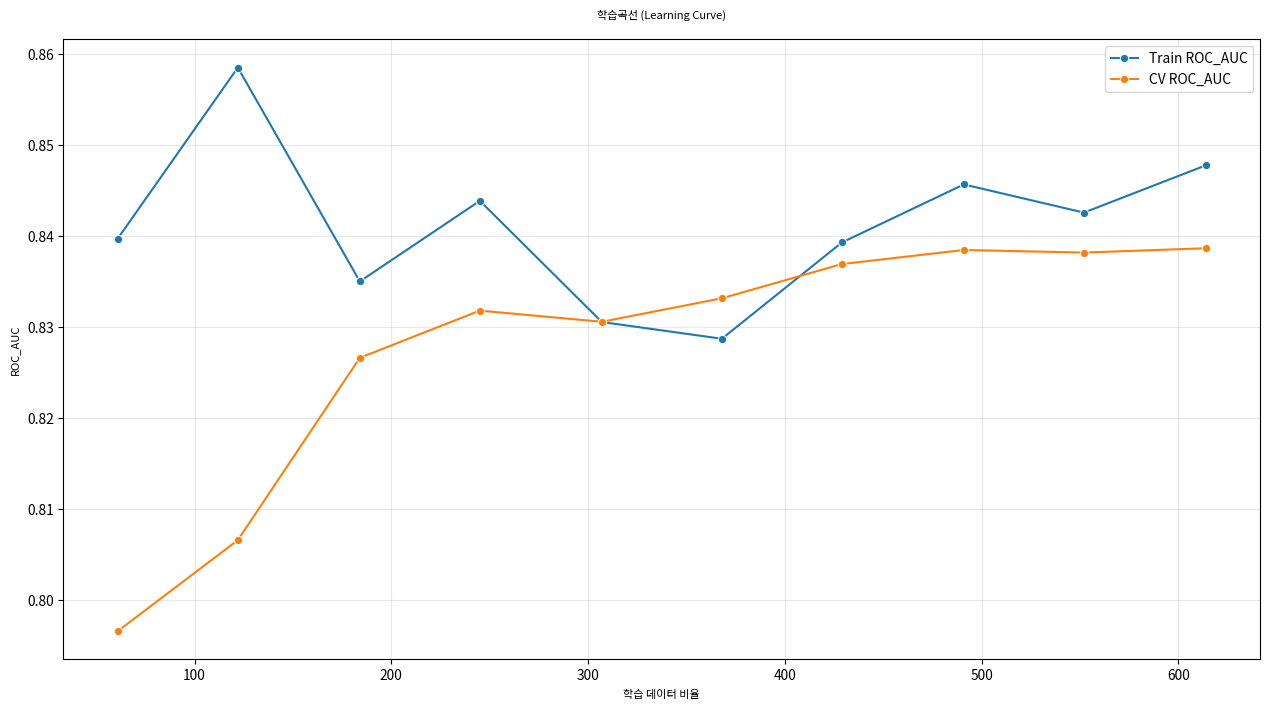

,Train ROC_AUC,CV ROC_AUC 평균,CV ROC_AUC 표준편차,Train/CV 비율,CV 변동성 비율,판정 결과
LogisticRegression,0.848,0.839,0.030,0.009,0.030,✅ 일반화 양호


: 

In [ ]:
hs_learning_cv(estimator, X, y)